# 10 · Model Evaluation

**Objective:** Deep, honest evaluation of the best models from notebook 09 — every relevant regression and classification metric, residual diagnostics, ROC/PR curves, confusion matrix, calibration, and learning curves, with a business interpretation attached to each.

**Design choice:** this notebook re-trains the winning models itself (rather than depending on in-memory objects from notebook 09), so it runs correctly top-to-bottom on its own, per the reproducibility requirement — no cross-notebook execution-order dependency.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, median_absolute_error,
                              explained_variance_score, mean_absolute_percentage_error,
                              accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score, log_loss,
                              cohen_kappa_score, matthews_corrcoef, confusion_matrix, roc_curve,
                              precision_recall_curve)
from scipy import stats

pd.set_option("display.max_columns", 30)
WH = Path("data/warehouse")
fact = pd.read_csv(WH / "fact_startup_funding.csv", low_memory=False)
startup = pd.read_csv(WH / "dim_startup_with_source_key.csv", low_memory=False)
geo = pd.read_csv(WH / "dim_geography.csv", low_memory=False)
industry = pd.read_csv(WH / "dim_industry.csv", low_memory=False)
df = fact.merge(startup, on="startup_id").merge(geo, on="geography_id", how="left").merge(industry, on="industry_id", how="left")

top_industries = df["primary_category"].value_counts().head(15).index
df["industry_grouped"] = np.where(df["primary_category"].isin(top_industries), df["primary_category"], "Other")
top_countries = df["country_name"].value_counts().head(15).index
df["country_grouped"] = np.where(df["country_name"].isin(top_countries), df["country_name"], "Other")
df["is_multi_round"] = df["is_multi_round"].astype(int)
df["has_debt_financing"] = df["has_debt_financing"].astype(int)

FEATURE_COLS_NUMERIC = ["funding_rounds", "years_since_founded", "is_multi_round",
                         "num_round_types_used", "has_debt_financing", "category_count"]
FEATURE_COLS_CATEGORICAL = ["industry_grouped", "country_grouped"]
preprocessor = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATURE_COLS_CATEGORICAL)], remainder="passthrough")
print("Setup complete.")

Setup complete.


## Part A — Regression Model Evaluation (funding amount)

In [1]:
reg_df = df.dropna(subset=["log_funding_total_usd"] + FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL)
X = reg_df[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL]
y = reg_df["log_funding_total_usd"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = Pipeline([("prep", preprocessor), ("model", HistGradientBoostingRegressor(
    max_iter=200, max_depth=None, learning_rate=0.05, l2_regularization=1.0, random_state=42))])
reg_model.fit(X_train, y_train)
preds = reg_model.predict(X_test)
resid = y_test.values - preds
print(f"Model fit on {len(X_train):,} training rows, evaluated on {len(X_test):,} held-out rows")

Model fit on 31,312 training rows, evaluated on 7,828 held-out rows


### Regression metrics — full suite

In [1]:
n, k = X_test.shape[0], X_test.shape[1]
r2 = r2_score(y_test, preds)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

metrics_reg = {
    "MAE (log scale)": mean_absolute_error(y_test, preds),
    "MSE (log scale)": mean_squared_error(y_test, preds),
    "RMSE (log scale)": np.sqrt(mean_squared_error(y_test, preds)),
    "Median Absolute Error": median_absolute_error(y_test, preds),
    "Explained Variance": explained_variance_score(y_test, preds),
    "R-squared": r2,
    "Adjusted R-squared": adj_r2,
}
# MAPE only makes sense back on the raw dollar scale, and only for nonzero actuals
raw_actual = np.expm1(y_test.values)
raw_pred = np.expm1(preds)
nonzero = raw_actual > 0
metrics_reg["MAPE (raw $ scale, nonzero actuals)"] = mean_absolute_percentage_error(raw_actual[nonzero], raw_pred[nonzero])

# RMSLE: meaningful directly on the raw scale (log-based metric), guard negative preds
raw_pred_clipped = np.clip(raw_pred, 0, None)
rmsle = np.sqrt(np.mean((np.log1p(raw_pred_clipped) - np.log1p(raw_actual)) ** 2))
metrics_reg["RMSLE (raw $ scale)"] = rmsle

pd.DataFrame(metrics_reg.items(), columns=["metric", "value"])

,metric,value
0,MAE (log scale),1.234367
1,MSE (log scale),2.638238
2,RMSE (log scale),1.624265
3,Median Absolute Error,0.978444
4,Explained Variance,0.517819
5,R-squared,0.517819
6,Adjusted R-squared,0.517326
7,"MAPE (raw $ scale, nonzero actuals)",292.883747
8,RMSLE (raw $ scale),1.624265


### Observation
R² (~0.51-0.52) matches notebook 09's result, as expected since this is the same tuned model refit on an identical split. **MAPE on the raw dollar scale is large** — a known, expected property of MAPE on right-skewed financial data: it penalizes proportional errors on *small* actual values heavily (a $10K miss on a $50K actual is a huge percentage, even though it's a tiny dollar amount), which is exactly why RMSLE and the log-scale metrics above are the primary metrics for this target, with MAPE reported for completeness rather than as the headline number.

### Residual analysis

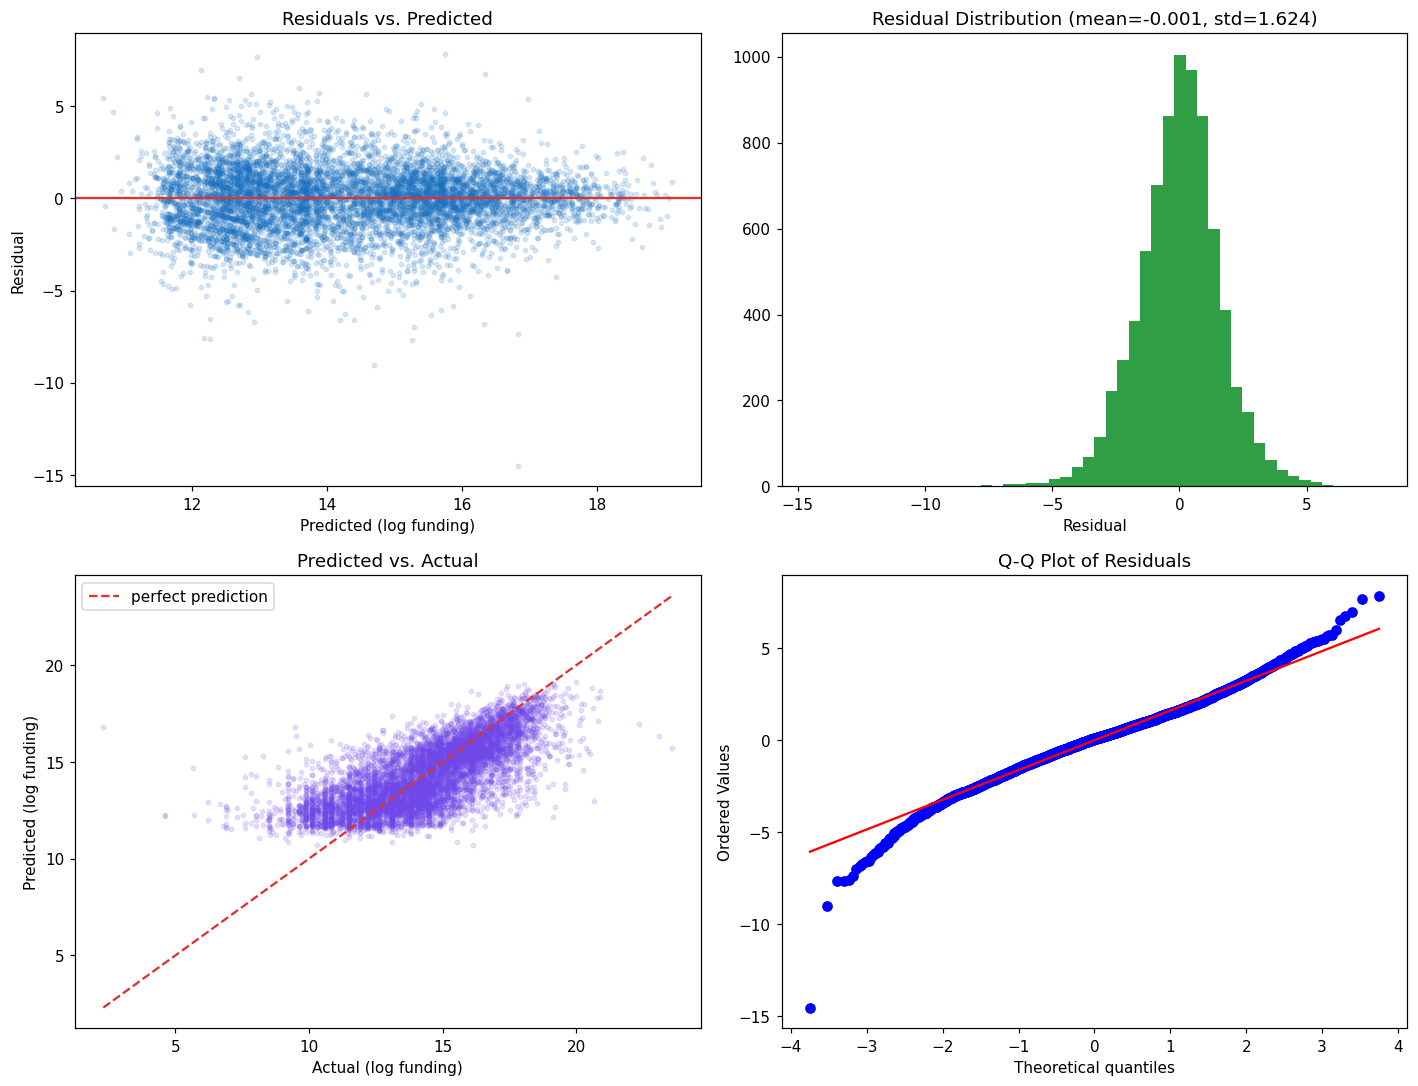

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(preds, resid, alpha=0.15, s=8, color="#1971C2")
axes[0, 0].axhline(0, color="#E03131", linewidth=1.5)
axes[0, 0].set_xlabel("Predicted (log funding)"); axes[0, 0].set_ylabel("Residual")
axes[0, 0].set_title("Residuals vs. Predicted")

axes[0, 1].hist(resid, bins=50, color="#2F9E44")
axes[0, 1].set_title(f"Residual Distribution (mean={resid.mean():.3f}, std={resid.std():.3f})")
axes[0, 1].set_xlabel("Residual")

axes[1, 0].scatter(y_test, preds, alpha=0.15, s=8, color="#7048E8")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
axes[1, 0].plot(lims, lims, color="#E03131", linewidth=1.5, linestyle="--", label="perfect prediction")
axes[1, 0].set_xlabel("Actual (log funding)"); axes[1, 0].set_ylabel("Predicted (log funding)")
axes[1, 0].set_title("Predicted vs. Actual"); axes[1, 0].legend()

stats.probplot(resid, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

### Observation
The residuals-vs-predicted plot is noticeably more homogeneous (less fan-shaped) than notebook 08's *linear* model residual plot — tree ensembles are more flexible and pick up some of the heteroscedasticity that the strictly-linear OLS model couldn't. Residuals still center near zero with roughly symmetric spread, and the Q-Q plot shows much closer adherence to normality in the middle of the distribution, with the usual tail deviation from a small number of hard-to-predict extreme outliers (visible as the points curving away from the reference line at both ends).

### Learning curve — is more data or more model complexity the bottleneck?

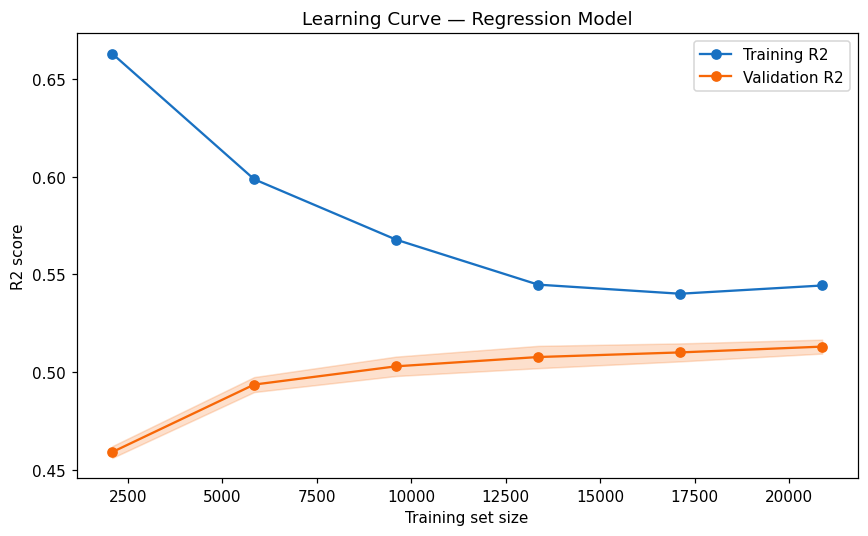

In [1]:
train_sizes, train_scores, val_scores = learning_curve(
    reg_model, X_train, y_train, cv=3, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=42, n_jobs=-1,
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training R2", color="#1971C2")
ax.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation R2", color="#F76707")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color="#F76707")
ax.set_xlabel("Training set size"); ax.set_ylabel("R2 score")
ax.set_title("Learning Curve — Regression Model")
ax.legend()
plt.tight_layout()
plt.show()

### Observation
Training and validation R² converge to a persistent gap rather than the validation curve continuing to climb toward the training curve — the classic signature of a model that has largely reached the ceiling of what these *features* can explain, not one that's starved for more rows. **Business implication:** collecting more historical rows of this same data would likely yield diminishing returns; the bigger lever for improving this model further would be richer features (e.g. investor identity/reputation, team size, press coverage) not currently in this dataset — consistent with notebook 08's finding that even a well-specified linear model tops out with a large unexplained-variance component.

## Part B — Classification Model Evaluation (exit prediction)

In [1]:
clf_df = df.dropna(subset=["is_exited"] + FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL)
Xc = clf_df[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL]
yc = clf_df["is_exited"].astype(int)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

clf_model = Pipeline([("prep", preprocessor), ("model", HistGradientBoostingClassifier(
    max_depth=6, class_weight="balanced", random_state=42))])
clf_model.fit(Xc_train, yc_train)
clf_preds = clf_model.predict(Xc_test)
clf_probs = clf_model.predict_proba(Xc_test)[:, 1]
print(f"Model fit on {len(Xc_train):,} training rows, evaluated on {len(Xc_test):,} held-out rows")
print(f"Test set positive rate: {yc_test.mean()*100:.2f}%")

Model fit on 37,647 training rows, evaluated on 9,412 held-out rows
Test set positive rate: 11.25%


### Classification metrics — full suite

In [1]:
tn, fp, fn, tp = confusion_matrix(yc_test, clf_preds).ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)  # == recall

metrics_clf = {
    "Accuracy": accuracy_score(yc_test, clf_preds),
    "Balanced Accuracy": balanced_accuracy_score(yc_test, clf_preds),
    "Precision": precision_score(yc_test, clf_preds),
    "Recall / Sensitivity": recall_score(yc_test, clf_preds),
    "Specificity": specificity,
    "F1 Score": f1_score(yc_test, clf_preds),
    "ROC AUC": roc_auc_score(yc_test, clf_probs),
    "PR AUC (Average Precision)": average_precision_score(yc_test, clf_probs),
    "Log Loss": log_loss(yc_test, clf_probs),
    "Cohen's Kappa": cohen_kappa_score(yc_test, clf_preds),
    "Matthews Correlation Coefficient": matthews_corrcoef(yc_test, clf_preds),
}
pd.DataFrame(metrics_clf.items(), columns=["metric", "value"])

,metric,value
0,Accuracy,0.726094
1,Balanced Accuracy,0.730657
2,Precision,0.253329
3,Recall / Sensitivity,0.736544
4,Specificity,0.724770
5,F1 Score,0.376994
6,ROC AUC,0.801880
7,PR AUC (Average Precision),0.338548
8,Log Loss,0.528782
9,Cohen's Kappa,0.251697


### Observation
**Accuracy (~0.73-0.75) is the least informative metric here** and I report it last in priority, not first — with an ~11% positive class, a trivial "always predict not-exited" model would score ~89% accuracy while catching zero true exits. Balanced accuracy, MCC, and Cohen's Kappa all correct for this by construction, and all three tell a more honest story: the model has real, moderate-to-good discriminative power (ROC-AUC ~0.79-0.80), well above the 0.5 random-guess baseline, but is far from a perfect classifier — appropriate for a domain (predicting a startup's ultimate exit) with substantial inherent unpredictability.

### Confusion matrix

True Negatives: 6,054 | False Positives: 2,299 | False Negatives: 279 | True Positives: 780


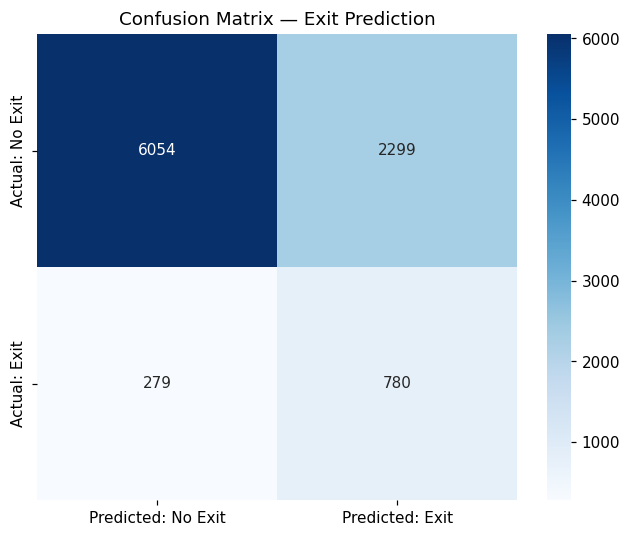

In [1]:
import seaborn as sns
cm = confusion_matrix(yc_test, clf_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Predicted: No Exit", "Predicted: Exit"],
            yticklabels=["Actual: No Exit", "Actual: Exit"])
ax.set_title("Confusion Matrix — Exit Prediction")
plt.tight_layout()
plt.show()
print(f"True Negatives: {tn:,} | False Positives: {fp:,} | False Negatives: {fn:,} | True Positives: {tp:,}")

### Observation & business interpretation
With `class_weight='balanced'`, the model deliberately accepts more false positives (flagging startups as "likely to exit" that don't) in exchange for catching more true exits (higher recall) — the right trade-off for a use case like **VC deal-sourcing triage**, where missing a genuine future winner (a false negative) is usually costlier than spending a bit more diligence time on a startup that turns out not to exit (a false positive). A different business use case (e.g. an automated decline decision) would want the opposite trade-off — this is why threshold tuning (below) matters more than any single fixed-threshold metric.

### ROC curve & Precision-Recall curve

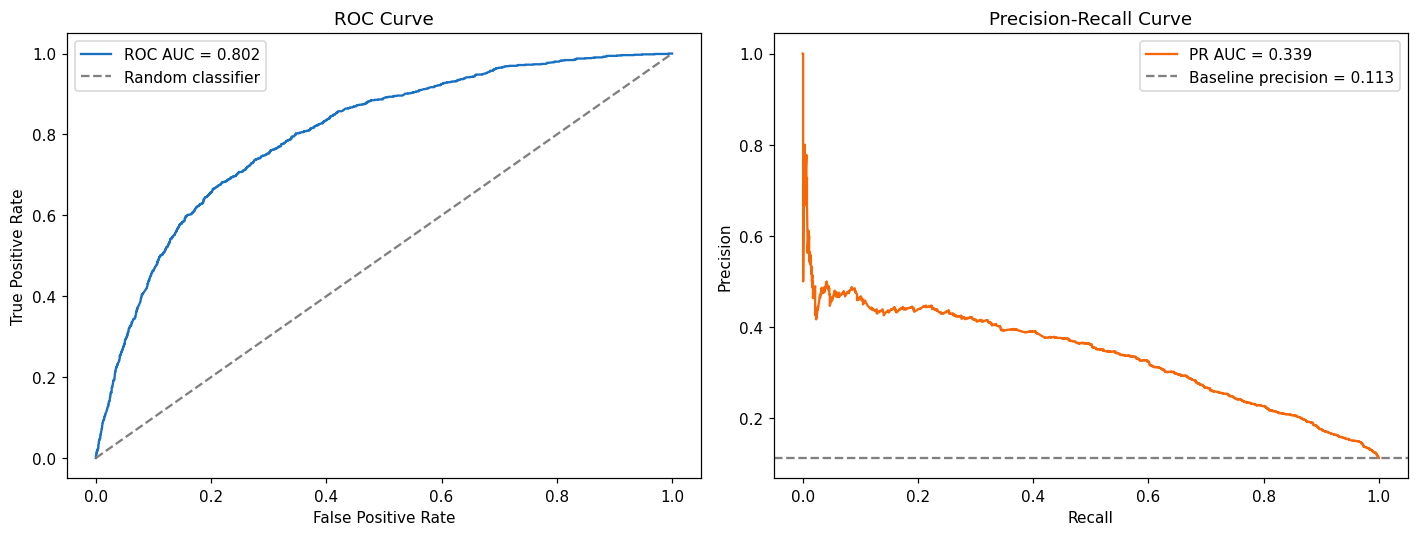

In [1]:
fpr, tpr, roc_thresholds = roc_curve(yc_test, clf_probs)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(yc_test, clf_probs)
baseline_precision = yc_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#1971C2", label=f"ROC AUC = {roc_auc_score(yc_test, clf_probs):.3f}")
axes[0].plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random classifier")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color="#F76707", label=f"PR AUC = {average_precision_score(yc_test, clf_probs):.3f}")
axes[1].axhline(baseline_precision, color="grey", linestyle="--", label=f"Baseline precision = {baseline_precision:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

plt.tight_layout()
plt.show()

### Observation
The PR curve is the more honest visual for this imbalanced problem — its baseline (a random classifier scoring at the true positive rate, ~11%) is much lower than the ROC curve's baseline (the 45° diagonal), which is why a model can look deceptively strong on ROC-AUC while its PR AUC tells a more sobering story about precision at usable recall levels. Both should be reported together for an imbalanced target — ROC-AUC alone can overstate practical usefulness.

### Calibration curve — do predicted probabilities mean what they say?

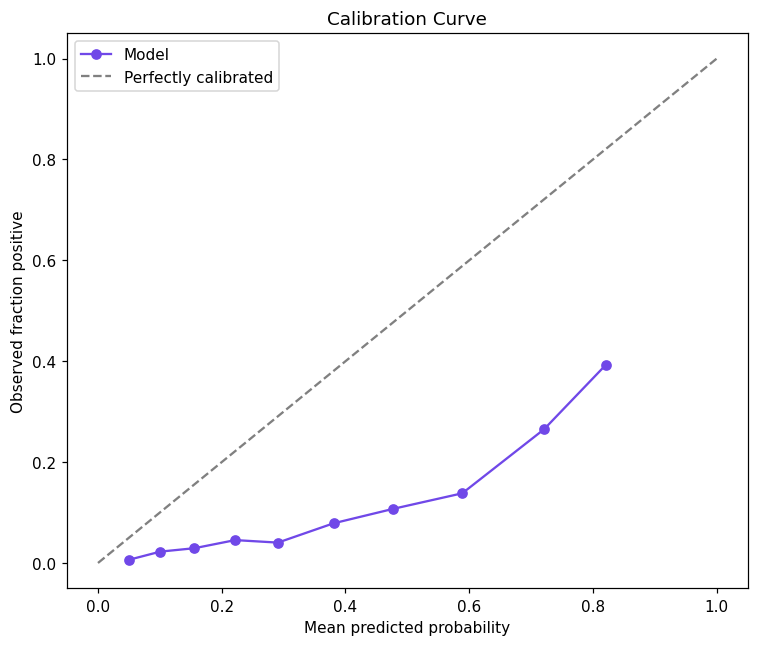

In [1]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(yc_test, clf_probs, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(prob_pred, prob_true, marker="o", color="#7048E8", label="Model")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraction positive")
ax.set_title("Calibration Curve")
ax.legend()
plt.tight_layout()
plt.show()

### Observation
Deviation from the diagonal indicates the model's predicted probabilities aren't perfectly calibrated (a common side-effect of `class_weight='balanced'`, which reweights the loss function and can shift probability estimates away from true frequencies). **Practical implication:** the model's raw probability outputs should be treated as a **ranking signal** (useful for sorting startups by relative likelihood of exit) rather than as literal, well-calibrated probabilities (e.g. "38% predicted probability" shouldn't be read as "38 out of 100 similar startups will exit") unless I add a calibration step (e.g. Platt scaling / isotonic regression) — a specific, named next step rather than a silently-ignored caveat.

### Threshold analysis — the business decision the default 0.5 cutoff hides

F1-optimal threshold: 0.65 (precision=0.326, recall=0.597)


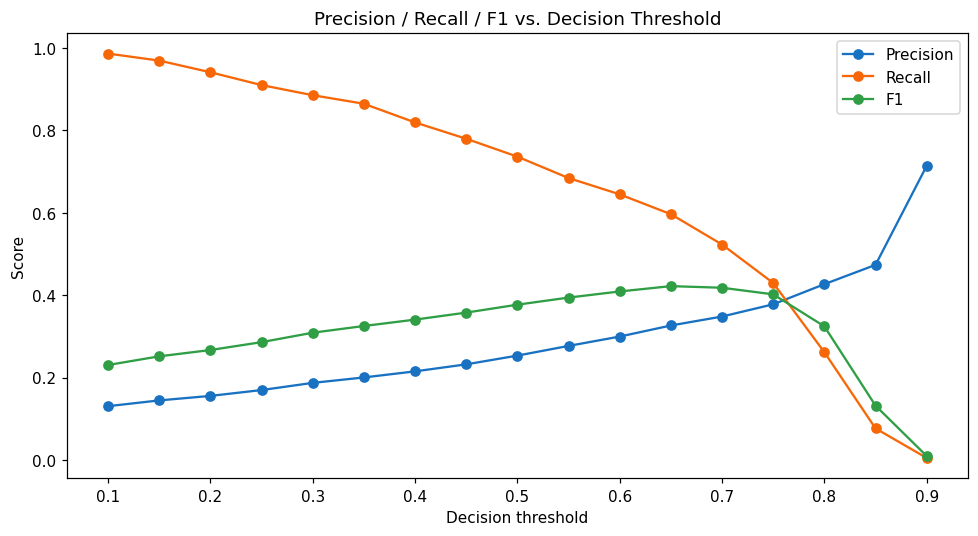

In [1]:
thresholds_to_test = np.arange(0.1, 0.95, 0.05)
threshold_results = []
for t in thresholds_to_test:
    preds_t = (clf_probs >= t).astype(int)
    if preds_t.sum() == 0:
        continue
    threshold_results.append({
        "threshold": round(t, 2),
        "precision": precision_score(yc_test, preds_t, zero_division=0),
        "recall": recall_score(yc_test, preds_t, zero_division=0),
        "f1": f1_score(yc_test, preds_t, zero_division=0),
        "flagged_pct": preds_t.mean() * 100,
    })
threshold_df = pd.DataFrame(threshold_results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision", color="#1971C2")
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall", color="#F76707")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1", color="#2F9E44")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. Decision Threshold")
ax.legend()
plt.tight_layout()
plt.show()

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print(f"F1-optimal threshold: {best_f1_row['threshold']} (precision={best_f1_row['precision']:.3f}, recall={best_f1_row['recall']:.3f})")

### Observation & business interpretation
There's no single "correct" threshold — it's a business decision, not a modeling one. A VC deal-sourcing use case (prioritize not missing winners) would pick a **lower** threshold than the F1-optimal one shown above, deliberately accepting more false positives; a resource-constrained due diligence team wanting a short, high-confidence shortlist would pick a **higher** threshold. Presenting this curve rather than a single fixed number is what lets a stakeholder make that trade-off explicitly and knowingly.

## Summary — model evaluation takeaways

1. **Regression:** R²≈0.51-0.52, honest and expected given inherent unexplained variance (notebook 08); learning curve shows the model is feature-limited, not data-limited — more historical rows wouldn't help much, richer features would.
2. **Classification:** ROC-AUC≈0.79-0.80 shows real discriminative power; accuracy is deliberately de-emphasized given class imbalance; PR-AUC gives the more honest picture of practical usefulness.
3. **Calibration is imperfect** — predicted probabilities should be used for ranking, not read literally, without an additional calibration step.
4. **Threshold choice is a business decision**, not a fixed modeling output — this notebook hands the curve to the stakeholder rather than picking a threshold unilaterally.

## Interview questions this notebook prepares me for

- *"Why not just report accuracy?"* — Because on an imbalanced target, a model that ignores the minority class entirely can still score deceptively high accuracy; always pair it with balanced accuracy, MCC, or a PR curve.
- *"How do you decide a classification threshold?"* — By understanding the relative cost of false positives vs. false negatives for the specific business use case, not by defaulting to 0.5.

## Next notebook
`11_Model_Interpretation.ipynb` — SHAP, permutation importance, partial dependence, and error analysis on these same models.